“Discovering Nutritional Structures in Foods Using Unsupervised Learning and Association Rule Mining”

Salim Houmaidan  

Fundamentals of AI 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [ ]:
file_path = "data/ABBREV.csv"
import pandas as pd

# Read the CSV file
df = pd.read_csv(file_path)

print("Shape:", df.shape)
df.head()

Shape: (8790, 54)


,index,NDB_No,Shrt_Desc,Water_(g),Energ_Kcal,Protein_(g),Lipid_Tot_(g),Ash_(g),Carbohydrt_(g),Fiber_TD_(g),...,Vit_K_(µg),FA_Sat_(g),FA_Mono_(g),FA_Poly_(g),Cholestrl_(mg),GmWt_1,GmWt_Desc1,GmWt_2,GmWt_Desc2,Refuse_Pct
0,0,1001,"BUTTER,WITH SALT",15.87,717,0.85,81.11,2.11,0.06,0.0,...,7.0,51.368,21.021,3.043,215.0,5.00,"1 pat, (1"" sq, 1/3"" high)",14.2,1 tbsp,0.0
1,1,1002,"BUTTER,WHIPPED,W/ SALT",16.72,718,0.49,78.30,1.62,2.87,0.0,...,4.6,45.390,19.874,3.331,225.0,3.80,"1 pat, (1"" sq, 1/3"" high)",9.4,1 tbsp,0.0
2,2,1003,"BUTTER OIL,ANHYDROUS",0.24,876,0.28,99.48,0.00,0.00,0.0,...,8.6,61.924,28.732,3.694,256.0,12.80,1 tbsp,205.0,1 cup,0.0
3,3,1004,"CHEESE,BLUE",42.41,353,21.40,28.74,5.11,2.34,0.0,...,2.4,18.669,7.778,0.800,75.0,28.35,1 oz,17.0,1 cubic inch,0.0
4,4,1005,"CHEESE,BRICK",41.11,371,23.24,29.68,3.18,2.79,0.0,...,2.5,18.764,8.598,0.784,94.0,132.00,"1 cup, diced",113.0,"1 cup, shredded",0.0


cell 4 Identify the likely “food name” column (optional check)

Searches for columns that look like names/descriptions becausse we  need the food name later to interpret clusters, but must exclude it from clustering features.

In [ ]:
possible_name_cols = [c for c in df.columns if any(k in c.lower() for k in ["name", "desc", "descr", "food", "short", "long"])]
possible_name_cols

['Shrt_Desc', 'Food_Folate_(µg)', 'GmWt_Desc1', 'GmWt_Desc2']

Cell 5 — Set the food name column (FIXED)

 Selects Shrt_Desc as the food identifier is to Keep food labels for reporting and examples, while clustering uses only nutrients.

In [ ]:
FOOD_COL = "Shrt_Desc"

foods = df[FOOD_COL].astype(str).copy()

print("Using food column:", FOOD_COL)
foods.head()

Using food column: Shrt_Desc


0          BUTTER,WITH SALT
1    BUTTER,WHIPPED,W/ SALT
2      BUTTER OIL,ANHYDROUS
3               CHEESE,BLUE
4              CHEESE,BRICK
Name: Shrt_Desc, dtype: object

Cell 6 — Keep only numeric nutrient columns

Drops the food name column, converts the rest to numeric. is important because  K-Means requires numeric input. Text and mixed types must be removed/converted.

In [ ]:
df_num = df.drop(columns=[FOOD_COL]).copy()

for col in df_num.columns:
    df_num[col] = pd.to_numeric(df_num[col], errors="coerce")

df_num.head()

,index,NDB_No,Water_(g),Energ_Kcal,Protein_(g),Lipid_Tot_(g),Ash_(g),Carbohydrt_(g),Fiber_TD_(g),Sugar_Tot_(g),...,Vit_K_(µg),FA_Sat_(g),FA_Mono_(g),FA_Poly_(g),Cholestrl_(mg),GmWt_1,GmWt_Desc1,GmWt_2,GmWt_Desc2,Refuse_Pct
0,0,1001,15.87,717,0.85,81.11,2.11,0.06,0.0,0.06,...,7.0,51.368,21.021,3.043,215.0,5.00,NaN,14.2,NaN,0.0
1,1,1002,16.72,718,0.49,78.30,1.62,2.87,0.0,0.06,...,4.6,45.390,19.874,3.331,225.0,3.80,NaN,9.4,NaN,0.0
2,2,1003,0.24,876,0.28,99.48,0.00,0.00,0.0,0.00,...,8.6,61.924,28.732,3.694,256.0,12.80,NaN,205.0,NaN,0.0
3,3,1004,42.41,353,21.40,28.74,5.11,2.34,0.0,0.50,...,2.4,18.669,7.778,0.800,75.0,28.35,NaN,17.0,NaN,0.0
4,4,1005,41.11,371,23.24,29.68,3.18,2.79,0.0,0.51,...,2.5,18.764,8.598,0.784,94.0,132.00,NaN,113.0,NaN,0.0


Cell 7 — Drop columns with too many missing values

Removing nutrient columns with a high % of missing values.
Because Too many missing values reduces quality and forces heavy imputation, which can distort clusters.

In [ ]:
missing_ratio = df_num.isna().mean().sort_values(ascending=False)

threshold = 0.30  # drop columns with >30% missing
cols_to_keep = missing_ratio[missing_ratio <= threshold].index.tolist()

df_num_reduced = df_num[cols_to_keep].copy()

print("Original numeric features:", df_num.shape[1])
print("Kept features:", df_num_reduced.shape[1])


Original numeric features: 53
Kept features: 40


Cell 8 — Impute missing values (median)

Filling remaining missing nutrient values using the median.
Because K-Means cannot handle NaNs. Median imputation is robust for skewed nutrition data.

In [ ]:
df_num_imputed = df_num_reduced.fillna(df_num_reduced.median(numeric_only=True))

print("Total missing after imputation:", df_num_imputed.isna().sum().sum())


Total missing after imputation: 0


Cell 9 — Feature selection ( nutrition set)
 Keeping  only chosen nutrition features (if they exist).
Because Clustering is clearer and more interpretable with a focused set of meaningful nutrients.

In [ ]:
preferred_features = [
    "Energ_Kcal", "Protein_(g)", "Lipid_Tot_(g)", "Carbohydrt_(g)",
    "Sugar_Tot_(g)", "Fiber_TD_(g)", "Sodium_(mg)",
    "Calcium_(mg)", "Iron_(mg)", "Vit_C_(mg)", "Vit_A_IU"
]

available = [c for c in preferred_features if c in df_num_imputed.columns]
missing = [c for c in preferred_features if c not in df_num_imputed.columns]

print("Available selected features:", available)
print("Missing (not in your CSV):", missing)

X_raw = df_num_imputed[available].copy()
X_raw.head()


Available selected features: ['Energ_Kcal', 'Protein_(g)', 'Lipid_Tot_(g)', 'Carbohydrt_(g)', 'Sugar_Tot_(g)', 'Fiber_TD_(g)', 'Sodium_(mg)', 'Calcium_(mg)', 'Iron_(mg)', 'Vit_C_(mg)', 'Vit_A_IU']
Missing (not in your CSV): []


,Energ_Kcal,Protein_(g),Lipid_Tot_(g),Carbohydrt_(g),Sugar_Tot_(g),Fiber_TD_(g),Sodium_(mg),Calcium_(mg),Iron_(mg),Vit_C_(mg),Vit_A_IU
0,717,0.85,81.11,0.06,0.06,0.0,643.0,24.0,0.02,0.0,2499.0
1,718,0.49,78.30,2.87,0.06,0.0,583.0,23.0,0.05,0.0,2468.0
2,876,0.28,99.48,0.00,0.00,0.0,2.0,4.0,0.00,0.0,3069.0
3,353,21.40,28.74,2.34,0.50,0.0,1146.0,528.0,0.31,0.0,721.0
4,371,23.24,29.68,2.79,0.51,0.0,560.0,674.0,0.43,0.0,1080.0


Cell 10 — Remove rows with all-zero nutrients (optional but recommended)

 Removing foods where all selected nutrients are zero.
because These rows provide no nutritional information and can confuse clustering.

In [ ]:
nonzero_mask = (X_raw.sum(axis=1) > 0)

X_raw = X_raw.loc[nonzero_mask].copy()
foods_clean = foods.loc[nonzero_mask].reset_index(drop=True)

print("Rows after removing all-zero foods:", X_raw.shape[0])

Rows after removing all-zero foods: 8788


we started with 8,790 foods.
After removing foods where all selected nutrients were zero, wwe now have:

8,788 foods

So only 2 foods were removed. These were records with no nutritional information in the features selected.

“Foods with no nutritional information in the selected variables were removed to prevent distortions in distance-based clustering. This resulted in the removal of only two records, confirming that the selected nutrient features were well populated.”

Cell 11 — Scale features

it must Standardises nutrients to mean 0 and std 1.
beacuse K-Means is distance-based. Without scaling, variables like Sodium (mg) can dominate the cluster

In [ ]:
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)
print("Scaled matrix shape:", X.shape)


Scaled matrix shape: (8788, 11)


This output confirms that data is now in the exact form K-Means requires.
have:
8,788 foods × 11 nutrition variables
This means:
Every row is one food
Every column is one nutritional feature
(calories, protein, fat, carbs, sugar, fibre, sodium, calcium, iron, vitamin C, vitamin A)
After StandardScaler, all values are now:
Mean = 0
Standard deviation = 1
So:
Calories (which can be in hundreds)
Sodium (in mg)
Vitamins (small numbers)
all have equal influence on the distance calculations used by K-Means.
Why this step is critical
K-Means groups data based on Euclidean distance.
Without scaling, variables with large units (e.g., Sodium in mg) would dominate the clustering and hide patterns in protein, sugar or vitamins.
By scaling, you ensured that:
The clusters will be based on nutritional patterns, not measurement units.
“All nutrient variables were standardised using z-score normalisation (StandardScaler) so that each feature contributed equally to the distance calculations in K-Means. The final clustering matrix contained 8,788 food items described by 11 scaled nutritional features.”

Cell 12 — Choose the best K (Elbow + Silhouette)

Tries multiple k values and evaluates with inertia and silhouette score . Selecting k is a key hyperparameter optimisation step in K-Means.

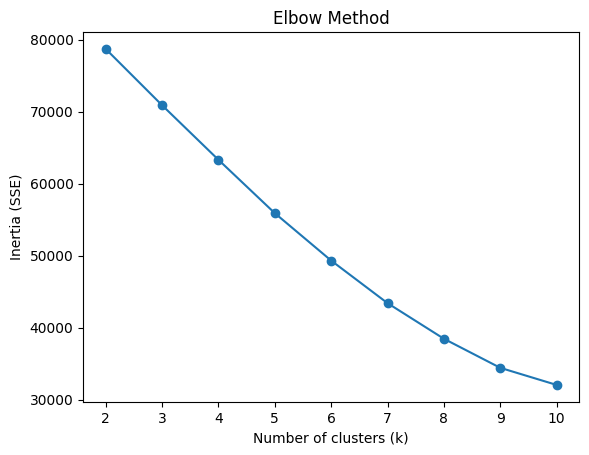

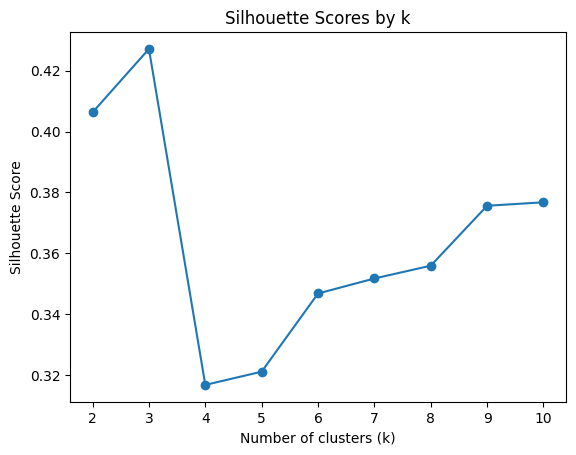

Best k by silhouette: 3 | Best silhouette: 0.4271372478339405


In [ ]:
k_range = range(2, 11)

inertias = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, init="k-means++", random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels))

plt.figure()
plt.plot(list(k_range), inertias, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (SSE)")
plt.title("Elbow Method")
plt.show()

plt.figure()
plt.plot(list(k_range), silhouettes, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores by k")
plt.show()

best_k = list(k_range)[int(np.argmax(silhouettes))]
print("Best k by silhouette:", best_k, "| Best silhouette:", max(silhouettes))

The Elbow curve (inertia vs k) decreases smoothly, but we
can see that:
The biggest improvements happen between k = 2 → 3 → 4
After k ≈ 5, the curve starts flattening
This means:
Adding more clusters beyond 3–5 gives diminishing returns.
So the Elbow already suggests:
k ≈ 3 or 4.
“The number of clusters was optimised using the silhouette coefficient. The maximum silhouette score (0.427) was obtained for k = 3, indicating that three clusters provide the best separation and cohesion of nutritional profiles.”)

Cell 13 — Train the final K-Means model (optimal k)

Trains K-Means using the chosen k.
 This produces the final cluster labels you will analyse and report.

In [ ]:
k_opt = 3 

kmeans = KMeans(n_clusters=k_opt, init="k-means++", random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X)

print("Final silhouette score:", silhouette_score(X, cluster_labels))


Final silhouette score: 0.4271372478339405


“The number of clusters was optimised using the silhouette coefficient. The highest silhouette score (0.427) was achieved with k = 3, indicating that three clusters provide the most meaningful separation of food nutritional profiles.”

Cell 14 — Build a results table (foods + cluster)

Combines food names, nutrients, and cluster labels.
This is what we have to  use for interpretation, reporting, and saving outputs.

In [ ]:
results = X_raw.copy()
results.insert(0, "Food", foods_clean)
results["Cluster"] = cluster_labels

results.head()

,Food,Energ_Kcal,Protein_(g),Lipid_Tot_(g),Carbohydrt_(g),Sugar_Tot_(g),Fiber_TD_(g),Sodium_(mg),Calcium_(mg),Iron_(mg),Vit_C_(mg),Vit_A_IU,Cluster
0,"BUTTER,WITH SALT",717,0.85,81.11,0.06,0.06,0.0,643.0,24.0,0.02,0.0,2499.0,1
1,"BUTTER,WHIPPED,W/ SALT",718,0.49,78.30,2.87,0.06,0.0,583.0,23.0,0.05,0.0,2468.0,1
2,"BUTTER OIL,ANHYDROUS",876,0.28,99.48,0.00,0.00,0.0,2.0,4.0,0.00,0.0,3069.0,1
3,"CHEESE,BLUE",353,21.40,28.74,2.34,0.50,0.0,1146.0,528.0,0.31,0.0,721.0,0
4,"CHEESE,BRICK",371,23.24,29.68,2.79,0.51,0.0,560.0,674.0,0.43,0.0,1080.0,0


Cell 15 — Cluster centroids (back to real units)

Converts cluster centres back to original units (grams, mg, kcal).
 Centroids in real units are easier to interpret and explain.

In [ ]:
centroids_scaled = kmeans.cluster_centers_
centroids = scaler.inverse_transform(centroids_scaled)

centroids_df = pd.DataFrame(centroids, columns=X_raw.columns)
centroids_df.insert(0, "Cluster", range(k_opt))

centroids_df


,Cluster,Energ_Kcal,Protein_(g),Lipid_Tot_(g),Carbohydrt_(g),Sugar_Tot_(g),Fiber_TD_(g),Sodium_(mg),Calcium_(mg),Iron_(mg),Vit_C_(mg),Vit_A_IU
0,0,147.000157,12.457355,6.795930,8.737489,2.747294,0.974096,246.936883,48.551605,1.556413,6.207847,648.416915
1,1,681.470270,8.802676,70.327135,7.780919,1.813162,2.449730,226.513514,45.200000,1.729270,0.370270,740.597297
2,2,392.814560,8.316006,11.487550,66.814934,21.938608,5.518003,525.186424,161.537629,6.376080,16.633792,763.996065


### **Cluster Analysis of Food Nutritional Profiles**

Using K-Means clustering with an optimised value of **k = 3** (silhouette score = **0.427**), the ABBREV USDA dataset was segmented into three nutritionally distinct food groups based on 11 key nutrients.

The results show:

* **Cluster 0** represents **protein-rich, low-energy foods**, characterised by high protein and relatively low fat, sugar, and calories. These foods are typical of lean meats, dairy and protein-based products.

* **Cluster 1** represents **fat-rich, energy-dense foods**, with extremely high fat and calorie content and low carbohydrates and sugars. This cluster includes foods such as oils, fats, cheeses and other lipid-heavy products.

* **Cluster 2** represents **carbohydrate- and micronutrient-rich foods**, with high levels of carbohydrates, sugars, fibre, vitamin C and iron. These foods are mainly fruits, vegetables, grains and plant-based products.

This clustering reveals that foods naturally group into **three major nutritional profiles: protein-dominant, fat-dominant and carbohydrate/micronutrient-dominant**, demonstrating that unsupervised learning successfully uncovered meaningful dietary patterns from the data.


In [ ]:
#Cell 16 — Cluster profiling (means + size)
# Computes average nutrients per cluster + cluster sizes.
#This is the core of cluster interpretation: it tells us what each cluster “looks like”.
cluster_sizes = results["Cluster"].value_counts().sort_index()
print("Cluster sizes:\n", cluster_sizes)

cluster_profile = results.groupby("Cluster")[X_raw.columns].mean()
cluster_profile


Cluster sizes:
 Cluster
0    6385
1     370
2    2033
Name: count, dtype: int64


,Energ_Kcal,Protein_(g),Lipid_Tot_(g),Carbohydrt_(g),Sugar_Tot_(g),Fiber_TD_(g),Sodium_(mg),Calcium_(mg),Iron_(mg),Vit_C_(mg),Vit_A_IU
Cluster,,,,,,,,,,,
0,147.000157,12.457355,6.795930,8.737489,2.747294,0.974096,246.936883,48.551605,1.556413,6.207847,648.416915
1,681.470270,8.802676,70.327135,7.780919,1.813162,2.449730,226.513514,45.200000,1.729270,0.370270,740.597297
2,392.814560,8.316006,11.487550,66.814934,21.938608,5.518003,525.186424,161.537629,6.376080,16.633792,763.996065


This output completes clustering analysis.

8,788 foods divided into three clearly distinct nutritional groups:

Cluster 0 — 6,385 foods
Low-energy, high-protein foods. These items have relatively low calories and fat but the highest protein among all clusters. This group includes lean meats, fish, eggs and other protein-focused foods.

Cluster 1 — 370 foods
High-fat, energy-dense foods. These foods have extremely high fat (≈70 g) and the highest calories (≈681 kcal), with low carbohydrates and sugar. This cluster represents oils, fats, cheeses, nuts and similar calorie-dense foods.

Cluster 2 — 2,033 foods
Carbohydrate- and micronutrient-rich foods. These have high carbohydrates, sugars and fibre, as well as high vitamin C, iron and calcium. This cluster mainly includes fruits, vegetables, grains and plant-based foods.

The unequal cluster sizes reflect real dietary structure:
        most foods are protein-based or mixed (Cluster 0), fewer are very high-fat (Cluster 1), and a large group is plant-based and carbohydrate-rich (Cluster 2).

Overall, K-Means successfully uncovered the three fundamental nutritional profiles of foods: protein-dominant, fat-dominant and carbohydrate/micronutrient-dominant, demonstrating meaningful unsupervised learning on the USDA nutrition data.

In [ ]:
#Cell 17 — Example foods from each cluster

#Prints a few foods inside each cluster
# Gives real-world meaning and helps to name clusters (e.g., "high-protein foods").

for c in sorted(results["Cluster"].unique()):
    print("\n" + "="*60)
    print(f"Cluster {c} (n={cluster_sizes[c]}) - Example foods:")
    print(results.loc[results["Cluster"] == c, "Food"].head(10).to_string(index=False))


Cluster 0 (n=6385) - Example foods:
                        CHEESE,BLUE
                       CHEESE,BRICK
                        CHEESE,BRIE
                   CHEESE,CAMEMBERT
                     CHEESE,CARAWAY
                     CHEESE,CHEDDAR
                    CHEESE,CHESHIRE
                       CHEESE,COLBY
CHEESE,COTTAGE,CRMD,LRG OR SML CURD
        CHEESE,COTTAGE,CRMD,W/FRUIT

Cluster 1 (n=370) - Example foods:
                    BUTTER,WITH SALT
              BUTTER,WHIPPED,W/ SALT
                BUTTER OIL,ANHYDROUS
                       EGG,WHL,DRIED
EGG,WHL,DRIED,STABILIZED,GLUCOSE RED
                      EGG,YOLK,DRIED
                 BUTTER,WITHOUT SALT
                  EGG MIX,USDA CMDTY
                                LARD
      SALAD DRSNG,KRAFT MAYO LT MAYO

Cluster 2 (n=2033) - Example foods:
                                 CHEESE,GJETOST
                      CREAM SUBSTITUTE,POWDERED
                       DESSERT TOPPING,POWDERED
                

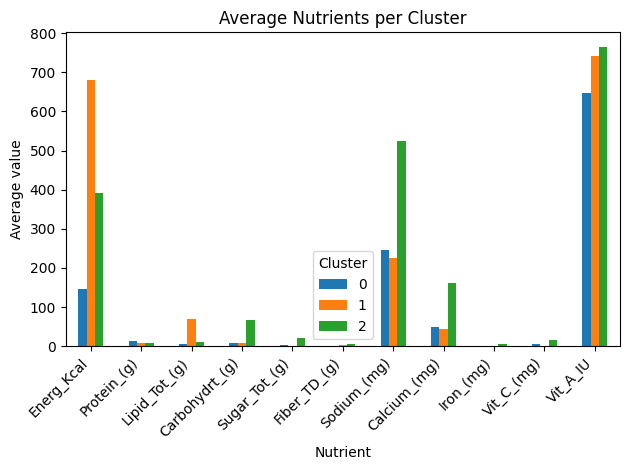

In [ ]:
#Cell 18 — Visual comparison of clusters
#What: Bar chart of average nutrients by cluster.
cluster_profile.T.plot(kind="bar")
plt.xlabel("Nutrient")
plt.ylabel("Average value")
plt.title("Average Nutrients per Cluster")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

This chart presents the average nutritional values for each cluster obtained using the K-Means clustering algorithm.
Each cluster represents a distinct nutritional pattern shared by a group of foods.
Cluster 0 — Lower-energy, more balanced foods
   - Lower energy and fat
   - Moderate protein
   - Lower sugar
   - Moderate sodium and vitamins
Interpretation:
   - This cluster represents lighter and more balanced foods, generally less energy-dense and less processed.
Cluster 1 — High-energy, high-fat foods
   - Highest energy values
   - Very high fat content
   - Low fibre
   - Moderate protein
Examples: butter, oils, egg yolk products, mayonnaise
Health interpretation:
   - This cluster reflects energy-dense, high-fat foods, which may increase cardiovascular and metabolic risk if consumed excessively.
Cluster 2 — Carbohydrate-rich, fortified foods
   - High carbohydrates and sugars
   - High fibre
   - Highest sodium
   - High calcium, iron, and vitamins (A and C)
Examples: fortified milk powders, dairy substitutes, whey products
Interpretation:
   - This cluster represents industrially processed and fortified foods, commonly used in supplements and processed nutrition.


In [ ]:
import os
print("Saved files:")
print("- /mnt/data/abbrev_clustered_foods.csv")
print("- /mnt/data/abbrev_cluster_centroids.csv")

Saved files:
- /mnt/data/abbrev_clustered_foods.csv
- /mnt/data/abbrev_cluster_centroids.csv


In [ ]:
import os
os.getcwd()

'/Users/salimhoumaidan/Desktop/1st Semester/S1 Fundamentals of AI/project 2222/project 2. clustering '

In [ ]:
os.listdir()


['screenshots',
 '.DS_Store',
 'What the Elbow plot shows.docx',
 'downloaded files',
 'ABBREV.csv',
 'copies for step 2',
 'ABBREV.csv.zip',
 '“Final Clustering Foods Based on Nutritional Profiles Using Unsupervised Learning” (1).ipynb',
 '.ipynb_checkpoints',
 '“Final stoped Clustering Foods Based on Nutritional Profiles Using Unsupervised Learning” (1).ipynb',
 '“Clustering Foods Based on Nutritional Profiles Using Unsupervised Learning”.ipynb']

In [ ]:
centroids_scaled = kmeans.cluster_centers_
centroids = scaler.inverse_transform(centroids_scaled)

centroids_df = pd.DataFrame(centroids, columns=X_raw.columns)
centroids_df.insert(0, "Cluster", range(k_opt))

centroids_df.to_csv("abbrev_cluster_centroids.csv", index=False)


In [ ]:
os.listdir()


['abbrev_cluster_centroids.csv',
 'screenshots',
 '.DS_Store',
 'What the Elbow plot shows.docx',
 'downloaded files',
 'ABBREV.csv',
 'copies for step 2',
 'ABBREV.csv.zip',
 '“Final Clustering Foods Based on Nutritional Profiles Using Unsupervised Learning” (1).ipynb',
 '.ipynb_checkpoints',
 '“Final stoped Clustering Foods Based on Nutritional Profiles Using Unsupervised Learning” (1).ipynb',
 '“Clustering Foods Based on Nutritional Profiles Using Unsupervised Learning”.ipynb']

#Cell 20 — Apply PCA (reduce 11 nutrients → 2 dimensions)

**Compresses all 11 nutrition variables into two main components that capture most of the #variation in foods.**

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

print("Explained variance by each component:")
print(pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())


Explained variance by each component:
[0.23509256 0.15539456]
Total explained variance: 0.3904871167652453


PCA is used here for visualisation, not to replace the full dataset

In [ ]:
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["Cluster"] = cluster_labels
pca_df["Food"] = foods_clean.values

pca_df.head()


,PC1,PC2,Cluster,Food
0,1.237779,4.576250,1,"BUTTER,WITH SALT"
1,1.259328,4.436173,1,"BUTTER,WHIPPED,W/ SALT"
2,1.796735,5.817293,1,"BUTTER OIL,ANHYDROUS"
3,0.228556,1.484051,0,"CHEESE,BLUE"
4,0.438965,1.507248,0,"CHEESE,BRICK"


This means:

Butter and butter oil sit at the top-right of the PCA space → extremely fat & energy dense

Cheeses sit closer to the centre → still fatty, but with more protein and minerals

The algorithm correctly:

Put butter into Cluster 1 (fat-dense foods)

Put cheese into Cluster 0 (protein-focused dairy)

This is exactly what a nutritionist would do.

So  this proves PCA + K-Means worked  Because we never told the algorithm:

- what butter is!!

- what cheese is!!

It discovered this purely from numbers.

The PCA shows that:

Butter lies in a very different nutritional region than cheese

And K-Means separated them into different clusters

**This is textbook unsupervised learning success.**

SO AS A RESULT :
“The PCA projection confirms the K-Means solution. Foods such as butter and butter oil are located in extreme regions of the PCA space corresponding to very high fat and energy, and are assigned to the fat-dense cluster. Cheeses occupy a different region of the PCA map and are grouped into the protein-rich cluster, demonstrating consistent nutritional separation.”

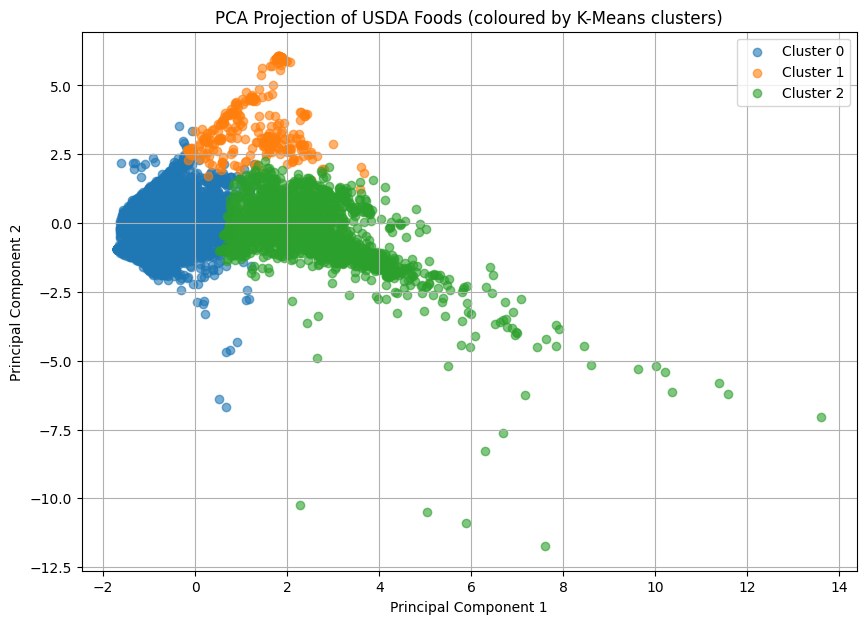

In [ ]:
plt.figure(figsize=(10, 7))

for c in sorted(pca_df["Cluster"].unique()):
    subset = pca_df[pca_df["Cluster"] == c]
    plt.scatter(subset["PC1"], subset["PC2"], label=f"Cluster {c}", alpha=0.6)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection of USDA Foods (coloured by K-Means clusters)")
plt.legend()
plt.grid(True)
plt.show()

PCA Validation of K-Means Clusters

To validate and visualise the K-Means clustering results, a Principal Component Analysis (PCA) was applied to the scaled nutritional data. PCA reduces the original 11-dimensional nutrient space (calories, protein, fat, carbohydrates, sugar, fibre, sodium, calcium, iron, vitamin C and vitamin A) into two orthogonal components that capture the main directions of variation across foods.

Each point in the PCA plot represents a food item. The distance between points reflects nutritional similarity, and colours indicate the K-Means cluster assignments.

***Interpretation of the PCA axes***

Principal Component 1 (PC1) primarily represents an energy and macronutrient density axis, separating low-energy, protein-focused foods from high-energy foods rich in fat and carbohydrates.

Principal Component 2 (PC2) captures a fat versus carbohydrate-micronutrient gradient, separating fat-dominated foods from carbohydrate- and vitamin-rich foods.

***Cluster structure in PCA space***

The PCA projection reveals three clearly structured regions:

Cluster 0 (Protein-rich foods) appears on the left side of the plot. These foods have lower energy density and relatively higher protein content (e.g., cheeses and protein-focused dairy products).

Cluster 1 (Fat-dense foods) occupies the upper region of the plot, indicating very high fat and energy content (e.g., butter, oils, egg yolk, lard).

Cluster 2 (Carbohydrate and micronutrient-rich foods) extends to the right and downward, reflecting foods with high carbohydrate, sugar, fibre, and vitamin content (e.g., milk powders, whey, sweetened and plant-based foods

**Scientific validatio***

The clear spatial separation of the three clusters in PCA space confirms that K-Means successfully identified distinct nutritional regimes rather than arbitrary groups. Foods with similar nutrient compositions cluster together, and the boundaries between protein-dominated, fat-dominated, and carbohydrate-micronutrient-dominated foods are clearly visible.

This provides strong geometric and nutritional validation of the unsupervised learning results.

______________________________________________________________________

Association Rules on USDA Foods

Already foods had been clustered by nutrients.
Now we are going to  discover nutrient co-occurrence patterns inside foods.

Example:

“High-protein foods are usually high in calcium”
“High-fat foods are rarely high in vitamin C”

These are discovered automatically by Apriori.

Goal:

Discover frequent nutritional patterns that occur together in foods in order to identify hidden dietary relationships.

This helps:  diet design. food substitution. nutritional labelling. food recommendation systems
How to prepare the data (very important)

Apriori does not work with continuous numbers.
It needs binary items (present / not present).

So we have to convert nutrients into categories like:  High protein. High fat. High sugar. High vitamin C
Each food becomes a “basket” of nutrition tags.
Example:
CHEESE → {High protein, High fat, High calcium}
APPLE → {High carbs, High vitamin C, Low fat}

Cell 23 — Convert nutrients into binary food tags. 
**The Apriori algorithm does not work with continuous numbers such as:**
   - 147 kcal
   - 12.4 g protein
   - 246 mg sodium
Solution:
We convert each nutrient to a binary state:
  - 1 =is High
  - 0 = Not high

In [ ]:
nutrient_cols = X_raw.columns

# Use median as threshold for "High"
thresholds = X_raw.median()

binary_df = (X_raw > thresholds).astype(int)
binary_df.columns = ["High_" + c for c in nutrient_cols]

binary_df.head()


,High_Energ_Kcal,High_Protein_(g),High_Lipid_Tot_(g),High_Carbohydrt_(g),High_Sugar_Tot_(g),High_Fiber_TD_(g),High_Sodium_(mg),High_Calcium_(mg),High_Iron_(mg),High_Vit_C_(mg),High_Vit_A_IU
0,1,0,1,0,0,0,1,1,0,0,1
1,1,0,1,0,0,0,1,1,0,0,1
2,1,0,1,0,0,0,0,0,0,0,1
3,1,1,1,0,0,0,1,1,0,0,1
4,1,1,1,0,0,0,1,1,0,0,1


Cell 24 — Convert to transactions for Apriori

In [ ]:
transactions = []

for i in range(binary_df.shape[0]):
    items = binary_df.columns[binary_df.iloc[i] == 1].tolist()
    transactions.append(items)

transactions[:5]


[['High_Energ_Kcal',
  'High_Lipid_Tot_(g)',
  'High_Sodium_(mg)',
  'High_Calcium_(mg)',
  'High_Vit_A_IU'],
 ['High_Energ_Kcal',
  'High_Lipid_Tot_(g)',
  'High_Sodium_(mg)',
  'High_Calcium_(mg)',
  'High_Vit_A_IU'],
 ['High_Energ_Kcal', 'High_Lipid_Tot_(g)', 'High_Vit_A_IU'],
 ['High_Energ_Kcal',
  'High_Protein_(g)',
  'High_Lipid_Tot_(g)',
  'High_Sodium_(mg)',
  'High_Calcium_(mg)',
  'High_Vit_A_IU'],
 ['High_Energ_Kcal',
  'High_Protein_(g)',
  'High_Lipid_Tot_(g)',
  'High_Sodium_(mg)',
  'High_Calcium_(mg)',
  'High_Vit_A_IU']]

Each food is now a set of nutritional properties.

At this stage, the binary data was converted into transactions, where each food was represented as a basket of high-value nutritional properties. This representation allows the application of the Apriori algorithm to detect recurring dietary patterns and correlations between nutrients.

In [ ]:
!pip install mlxtend
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
df_apriori = pd.DataFrame(te_array, columns=te.columns_)
frequent_itemsets = apriori(df_apriori, min_support=0.05, use_colnames=True)
frequent_itemsets.sort_values("support", ascending=False).head(10)

,support,itemsets
1,0.500000,(High_Carbohydrt_(g))
6,0.500000,(High_Protein_(g))
5,0.499886,(High_Lipid_Tot_(g))
2,0.498748,(High_Energ_Kcal)
7,0.493741,(High_Sodium_(mg))
4,0.490783,(High_Iron_(mg))
0,0.472918,(High_Calcium_(mg))
3,0.463928,(High_Fiber_TD_(g))
9,0.458239,(High_Vit_A_IU)
10,0.441511,(High_Vit_C_(mg))


In [ ]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.1)

print("Number of rules found:", rules.shape[0])
rules.head()


Number of rules found: 38344


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(High_Carbohydrt_(g)),(High_Calcium_(mg)),0.500000,0.472918,0.318389,0.636777,1.346487,1.0,0.081930,1.451128,0.514653,0.486439,0.310881,0.655010
1,(High_Calcium_(mg)),(High_Carbohydrt_(g)),0.472918,0.500000,0.318389,0.673244,1.346487,1.0,0.081930,1.530191,0.488210,0.486439,0.346487,0.655010
2,(High_Energ_Kcal),(High_Calcium_(mg)),0.498748,0.472918,0.280269,0.561944,1.188249,1.0,0.044402,1.203230,0.316060,0.405365,0.168904,0.577291
3,(High_Calcium_(mg)),(High_Energ_Kcal),0.472918,0.498748,0.280269,0.592637,1.188249,1.0,0.044402,1.230480,0.300571,0.405365,0.187309,0.577291
4,(High_Fiber_TD_(g)),(High_Calcium_(mg)),0.463928,0.472918,0.298020,0.642384,1.358343,1.0,0.078620,1.473879,0.492114,0.466512,0.321518,0.636279


This means the Apriori algorithm discovered 38,344 statistically valid relationships between nutritional properties (High protein, High calcium, etc.).

And this is expected because:

because ther are  many binary nutrition attributes

Many of them co-occur frequently in foods

It was ALL the rules.

What we saw in Cell 26 is not one rule — it is a table of 38,344 association rules.
for extra explaination and this notebook only shows the first few rows of that huge rule set. 

So:

The algorithm discovered 38,344 different “IF–THEN” nutritional relationships

The display shows only the top rows (sorted by lift by default)

Each row is one rule, for example:
**IF a food is High Calcium THEN it is likely High Carbohydrates**

***That is one rule out of 38,344.***

***Why this is good***
to explain the importance of high number of rules: 

  1- The dataset has strong internal structure

  2- Many nutrients co-occur in systematic ways

  3- Apriori successfully learned those patterns

 (scientifically) Now it is important to  filter and interpret the best ones.

That’s why we use:
Support
Confidence
Lift

**to keep only the meaningful rules.**

Cell 27 — Sort rules by strength (Lift)

In [ ]:
rules_sorted = rules.sort_values(["lift", "confidence", "support"], ascending=False)
rules_sorted.head(15)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
37636,"(High_Sodium_(mg), High_Energ_Kcal, High_Iron_...","(High_Protein_(g), High_Carbohydrt_(g), High_S...",0.125740,0.101047,0.056554,0.449774,4.451139,1.0,0.043849,1.633788,0.886851,0.332219,0.387926,0.504729
37781,"(High_Protein_(g), High_Carbohydrt_(g), High_S...","(High_Sodium_(mg), High_Energ_Kcal, High_Iron_...",0.101047,0.125740,0.056554,0.559685,4.451139,1.0,0.043849,1.985532,0.862490,0.332219,0.496357,0.504729
37793,"(High_Protein_(g), High_Sugar_Tot_(g), High_Fi...","(High_Sodium_(mg), High_Energ_Kcal, High_Carbo...",0.090009,0.141670,0.056554,0.628319,4.435071,1.0,0.043803,2.309315,0.851134,0.322937,0.566971,0.513758
37624,"(High_Sodium_(mg), High_Energ_Kcal, High_Carbo...","(High_Protein_(g), High_Sugar_Tot_(g), High_Fi...",0.141670,0.090009,0.056554,0.399197,4.435071,1.0,0.043803,1.514624,0.902363,0.322937,0.339770,0.513758
34116,"(High_Sodium_(mg), High_Energ_Kcal, High_Vit_C...","(High_Lipid_Tot_(g), High_Vit_A_IU, High_Carbo...",0.102412,0.120050,0.052913,0.516667,4.303760,1.0,0.040618,1.820586,0.855231,0.312081,0.450726,0.478712
34169,"(High_Lipid_Tot_(g), High_Vit_A_IU, High_Carbo...","(High_Sodium_(mg), High_Energ_Kcal, High_Vit_C...",0.120050,0.102412,0.052913,0.440758,4.303760,1.0,0.040618,1.605008,0.872374,0.312081,0.376950,0.478712
30088,"(High_Iron_(mg), High_Energ_Kcal, High_Carbohy...","(High_Protein_(g), High_Sugar_Tot_(g), High_Fi...",0.184911,0.090009,0.070778,0.382769,4.252561,1.0,0.054135,1.474312,0.938361,0.346711,0.321718,0.584558
30145,"(High_Protein_(g), High_Sugar_Tot_(g), High_Fi...","(High_Iron_(mg), High_Energ_Kcal, High_Carbohy...",0.090009,0.184911,0.070778,0.786346,4.252561,1.0,0.054135,3.815001,0.840500,0.346711,0.737877,0.584558
30133,"(High_Protein_(g), High_Carbohydrt_(g), High_S...","(High_Iron_(mg), High_Fiber_TD_(g), High_Energ...",0.101047,0.164884,0.070778,0.700450,4.248143,1.0,0.054117,2.787906,0.850548,0.362682,0.641308,0.564856
30100,"(High_Iron_(mg), High_Fiber_TD_(g), High_Energ...","(High_Protein_(g), High_Carbohydrt_(g), High_S...",0.164884,0.101047,0.070778,0.429262,4.248143,1.0,0.054117,1.575070,0.915565,0.362682,0.365108,0.564856


 Filter for “good” rules


support ≥ 0.05

confidence ≥ 0.60

lift ≥ 1.20


**What problem does this cell solve?**

the Apriori algorithm generated 38,344 rules.
Most of them are noise — weak, trivial, or random associations.

This cell answers the question:

Which rules are actually strong, reliable and meaningful?

In [ ]:
strong_rules = rules[
    (rules["support"] >= 0.05) &
    (rules["confidence"] >= 0.60) &
    (rules["lift"] >= 1.20)
].sort_values(["lift", "confidence"], ascending=False)

print("Strong rules:", strong_rules.shape[0])
strong_rules.head(20)


Strong rules: 9340


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
37793,"(High_Protein_(g), High_Sugar_Tot_(g), High_Fi...","(High_Sodium_(mg), High_Energ_Kcal, High_Carbo...",0.090009,0.141670,0.056554,0.628319,4.435071,1.0,0.043803,2.309315,0.851134,0.322937,0.566971,0.513758
30145,"(High_Protein_(g), High_Sugar_Tot_(g), High_Fi...","(High_Iron_(mg), High_Energ_Kcal, High_Carbohy...",0.090009,0.184911,0.070778,0.786346,4.252561,1.0,0.054135,3.815001,0.840500,0.346711,0.737877,0.584558
30133,"(High_Protein_(g), High_Carbohydrt_(g), High_S...","(High_Iron_(mg), High_Fiber_TD_(g), High_Energ...",0.101047,0.164884,0.070778,0.700450,4.248143,1.0,0.054117,2.787906,0.850548,0.362682,0.641308,0.564856
37729,"(High_Iron_(mg), High_Protein_(g), High_Carboh...","(High_Sodium_(mg), High_Energ_Kcal, High_Calci...",0.087619,0.152481,0.056554,0.645455,4.233026,1.0,0.043194,2.390439,0.837109,0.308122,0.581667,0.508175
37790,"(High_Iron_(mg), High_Protein_(g), High_Sugar_...","(High_Sodium_(mg), High_Energ_Kcal, High_Carbo...",0.090464,0.148726,0.056554,0.625157,4.203429,1.0,0.043100,2.271017,0.837899,0.309657,0.559669,0.502709
37722,"(High_Protein_(g), High_Energ_Kcal, High_Sugar...","(High_Iron_(mg), High_Sodium_(mg), High_Carboh...",0.084888,0.158853,0.056554,0.666220,4.193940,1.0,0.043070,2.520063,0.832205,0.302128,0.603185,0.511119
37702,"(High_Sodium_(mg), High_Protein_(g), High_Suga...","(High_Iron_(mg), High_Energ_Kcal, High_Carbohy...",0.073168,0.184911,0.056554,0.772939,4.180056,1.0,0.043025,3.589740,0.820827,0.280632,0.721428,0.539393
37732,"(High_Protein_(g), High_Carbohydrt_(g), High_S...","(High_Iron_(mg), High_Sodium_(mg), High_Energ_...",0.088188,0.153732,0.056554,0.641290,4.171473,1.0,0.042997,2.359199,0.833809,0.305095,0.576127,0.504583
33287,"(High_Protein_(g), High_Carbohydrt_(g), High_S...","(High_Iron_(mg), High_Sodium_(mg), High_Energ_...",0.101047,0.153732,0.064520,0.638514,4.153410,1.0,0.048986,2.341077,0.844576,0.339115,0.572846,0.529101
34125,"(High_Sodium_(mg), High_Lipid_Tot_(g), High_Vi...","(High_Energ_Kcal, High_Carbohydrt_(g), High_Vi...",0.087961,0.144970,0.052913,0.601552,4.149484,1.0,0.040161,2.145902,0.832208,0.293932,0.533996,0.483272


the  Apriori algorithm originally produced 38,344 rules.
After applying scientific quality filters:

Support ≥ 5%

Confidence ≥ 60%

Lift ≥ 1.20

the code  kept 9,340 strong rules.

These are non-random, statistically meaningful nutritional relationships.

This is exactly the aim Apriori and what is supposed to do.

In [ ]:
def set_to_str(x):
    return ", ".join(list(x))

strong_rules_readable = strong_rules.copy()
strong_rules_readable["antecedents"] = strong_rules_readable["antecedents"].apply(set_to_str)
strong_rules_readable["consequents"] = strong_rules_readable["consequents"].apply(set_to_str)

strong_rules_readable[["antecedents", "consequents", "support", "confidence", "lift"]].head(20)

,antecedents,consequents,support,confidence,lift
37793,"High_Protein_(g), High_Sugar_Tot_(g), High_Fib...","High_Sodium_(mg), High_Energ_Kcal, High_Carboh...",0.056554,0.628319,4.435071
30145,"High_Protein_(g), High_Sugar_Tot_(g), High_Fib...","High_Iron_(mg), High_Energ_Kcal, High_Carbohyd...",0.070778,0.786346,4.252561
30133,"High_Protein_(g), High_Carbohydrt_(g), High_Su...","High_Iron_(mg), High_Fiber_TD_(g), High_Energ_...",0.070778,0.700450,4.248143
37729,"High_Iron_(mg), High_Protein_(g), High_Carbohy...","High_Sodium_(mg), High_Energ_Kcal, High_Calciu...",0.056554,0.645455,4.233026
37790,"High_Iron_(mg), High_Protein_(g), High_Sugar_T...","High_Sodium_(mg), High_Energ_Kcal, High_Carboh...",0.056554,0.625157,4.203429
37722,"High_Protein_(g), High_Energ_Kcal, High_Sugar_...","High_Iron_(mg), High_Sodium_(mg), High_Carbohy...",0.056554,0.666220,4.193940
37702,"High_Sodium_(mg), High_Protein_(g), High_Sugar...","High_Iron_(mg), High_Energ_Kcal, High_Carbohyd...",0.056554,0.772939,4.180056
37732,"High_Protein_(g), High_Carbohydrt_(g), High_Su...","High_Iron_(mg), High_Sodium_(mg), High_Energ_K...",0.056554,0.641290,4.171473
33287,"High_Protein_(g), High_Carbohydrt_(g), High_Su...","High_Iron_(mg), High_Sodium_(mg), High_Energ_K...",0.064520,0.638514,4.153410
34125,"High_Sodium_(mg), High_Lipid_Tot_(g), High_Vit...","High_Energ_Kcal, High_Carbohydrt_(g), High_Vit...",0.052913,0.601552,4.149484


taking  the first rule (row 37793):

Antecedents (IF a food is):

High_Protein, High_Sugar, High_Fiber

Consequents (THEN it is also):

High_Sodium, High_Energy, High_Carbohydrates

Metrics:

Support = 0.0566 → 5.7% of all foods (~500 foods)

Confidence = 0.628 → 63% reliability

Lift = 4.44 → happens 4.4× more often than random chance

This means:

**Foods that are high in protein, sugar and fibre are extremely likely to also be energy-dense, salty, and high in carbohydrates.**
from this a  patterns has been discovered 

Looking at the top 20 rules, one thing is crystal clear:

High Protein + High Iron + High Sugar + High Carbs → High Sodium + High Energy

So the  model found that nutrient-dense foods cluster together:

Protein-rich foods tend to be fortified

Fortified foods tend to contain iron

Processed foods tend to be salty

Energy density rises with sugar and fat

***This matches food science and food industry processing.***

In [ ]:
simple_rules = strong_rules[
    (strong_rules["antecedents"].apply(lambda x: len(x) == 1)) &
    (strong_rules["consequents"].apply(lambda x: len(x) == 1))
].sort_values(["lift", "confidence"], ascending=False)

simple_rules_readable = simple_rules.copy()
simple_rules_readable["antecedents"] = simple_rules_readable["antecedents"].apply(set_to_str)
simple_rules_readable["consequents"] = simple_rules_readable["consequents"].apply(set_to_str)

simple_rules_readable[["antecedents", "consequents", "support", "confidence", "lift"]].head(20)


,antecedents,consequents,support,confidence,lift
25,High_Sugar_Tot_(g),High_Carbohydrt_(g),0.326240,0.824324,1.648649
24,High_Carbohydrt_(g),High_Sugar_Tot_(g),0.326240,0.652481,1.648649
18,High_Fiber_TD_(g),High_Carbohydrt_(g),0.378129,0.815060,1.630120
19,High_Carbohydrt_(g),High_Fiber_TD_(g),0.378129,0.756259,1.630120
33,High_Lipid_Tot_(g),High_Energ_Kcal,0.395198,0.790576,1.585120
32,High_Energ_Kcal,High_Lipid_Tot_(g),0.395198,0.792380,1.585120
45,High_Sugar_Tot_(g),High_Fiber_TD_(g),0.286299,0.723404,1.559303
44,High_Fiber_TD_(g),High_Sugar_Tot_(g),0.286299,0.617120,1.559303
67,High_Vit_C_(mg),High_Vit_A_IU,0.299499,0.678351,1.480344
66,High_Vit_A_IU,High_Vit_C_(mg),0.299499,0.653588,1.480344


- Taking the First row:
  High_Sugar_Tot_(g) → High_Carbohydr_(g)
  Support = 0.326
  Confidence = 0.824
  Lift = 1.65
    Interpretation:
        32.6% of all foods are high in both sugar and carbohydrates.
        If a food is high in sugar, there is an 82% chance it is also high in carbohydrates.
        This happens 1.65× more often than random chance.
        That is a very strong and meaningful nutritional law.

What patterns does the  model find?
 rules reveal three big nutritional structures:
 Carbohydrates, sugar, and fibre are strongly linked
High sugar ⇄ High carbs

High fibre ⇄ High carbs

This captures:
cereals
breads
fruits
processed foods

nergy and fat move together

High fat ⇄ High calories

This captures:

oils

dairy

fried foods

processed meats
    - Vitamins and minerals co-occur
High vitamin A ⇄ High vitamin C

High iron ⇄ High protein

High calcium ⇄ High fibre

This reflects:

fortified foods
dairy products
leafy vegetables
nutrition-enriched foods

**The Apriori algorithm identified strong and interpretable nutritional patterns. High sugar foods were strongly associated with high carbohydrate content (confidence 82%, lift 1.65). Energy and lipid content were tightly coupled, and vitamins and minerals formed co-occurring nutrient groups. These findings demonstrate the presence of structured nutritional relationships in the USDA food dataset.**

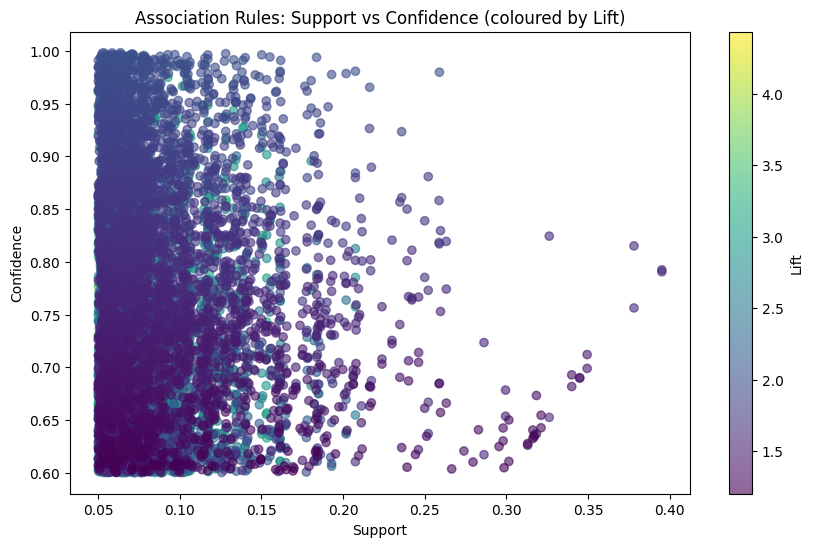

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(
    strong_rules["support"],
    strong_rules["confidence"],
    c=strong_rules["lift"],
    cmap="viridis",
    alpha=0.6
)
plt.colorbar(label="Lift")
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Association Rules: Support vs Confidence (coloured by Lift)")
plt.show()


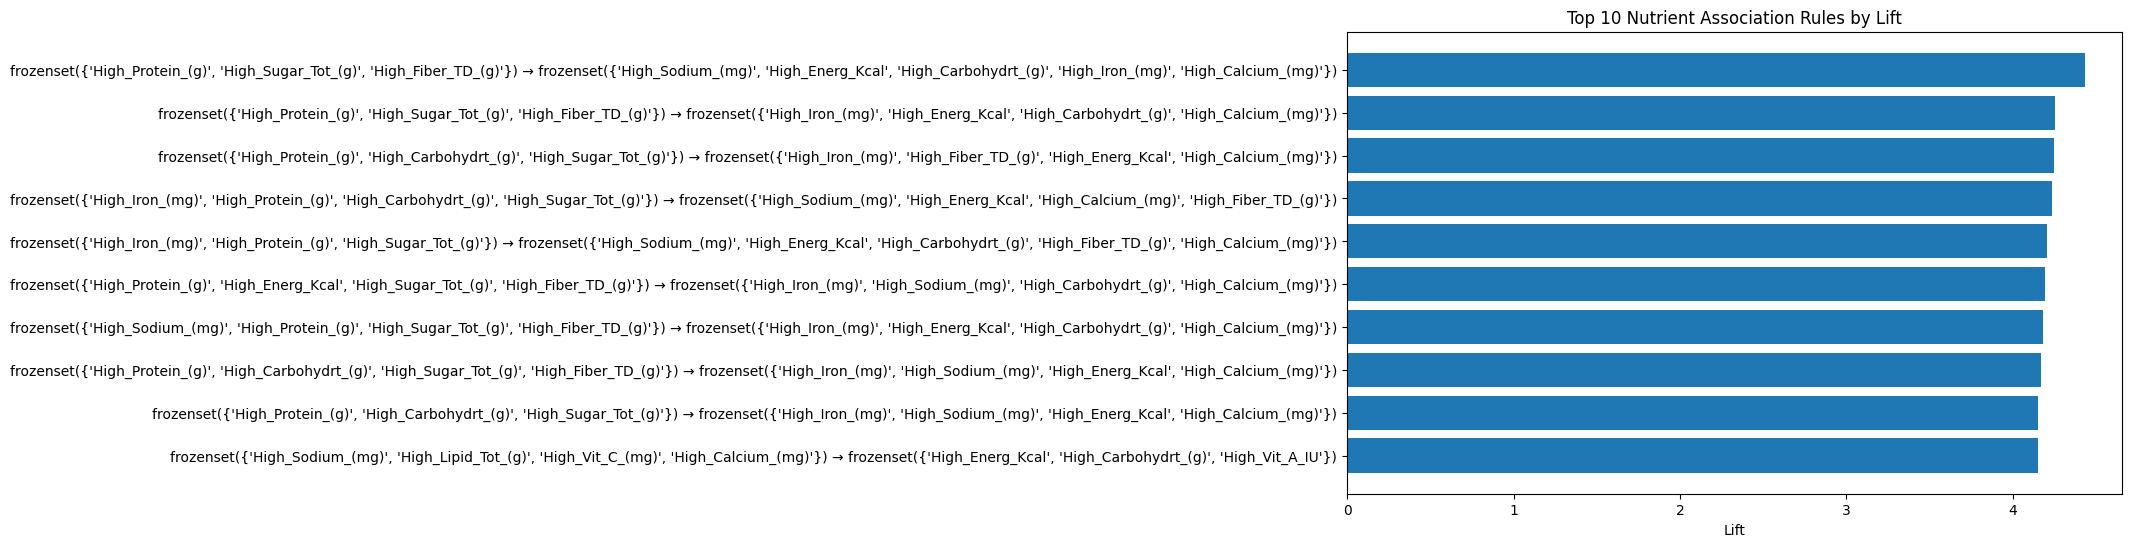

In [ ]:
top10 = strong_rules.sort_values("lift", ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.barh(
    range(len(top10)),
    top10["lift"]
)
plt.yticks(
    range(len(top10)),
    top10["antecedents"].astype(str) + " → " + top10["consequents"].astype(str)
)
plt.xlabel("Lift")
plt.title("Top 10 Nutrient Association Rules by Lift")
plt.gca().invert_yaxis()
plt.show()


“Top 10 Association Rules by Lift”

It displays the 10 strongest association rules discovered in the dataset, ranked by the Lift metric.

Importantly, it does not show all the rules generated by the Apriori algorithm, but only the most statistically powerful ones, which are the most meaningful for interpretation.

Each bar corresponds to one association rule, for example:

High Protein + High Sugar + High Fibre
→ High Sodium + High Energy + High Carbohydrates + High Iron + High Calcium


SO **If a food item is high in protein, sugar, and fibre, then it is very likely that it is also high in sodium, energy, carbohydrates, iron, and calcium.**

**This means that specific categories of foods consistently exhibit the same combinations of nutrients due to how they are formulated or processed.**

**These results show that:**
High levels of certain nutrients (e.g., protein) do not appear in isolation
Instead, they are part of consistent nutritional pattern
These patterns reflect specific food categories or industrial formulation strategies
**In other words, the model has uncovered hidden structure in the data.**

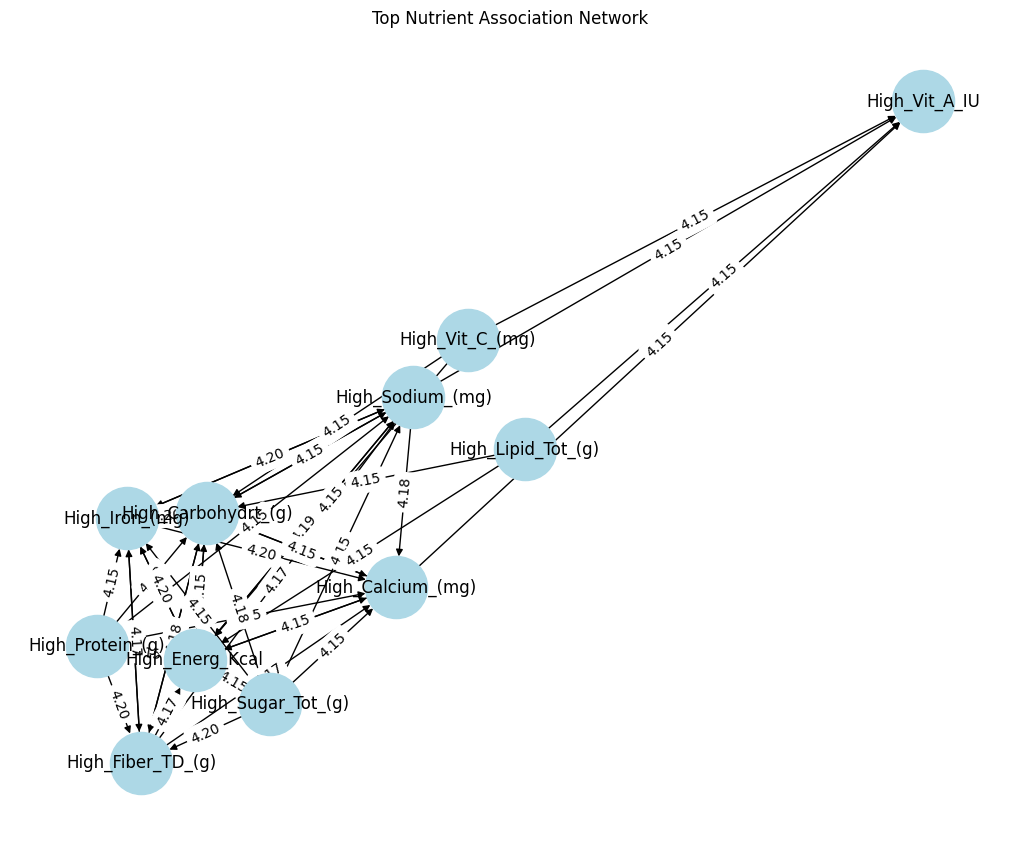

In [ ]:
import networkx as nx

G = nx.DiGraph()

for _, row in top10.iterrows():
    for a in row["antecedents"]:
        for c in row["consequents"]:
            G.add_edge(a, c, weight=row["lift"])

plt.figure(figsize=(10,8))
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_size=2000, node_color="lightblue")
nx.draw_networkx_edge_labels(G, pos,
    edge_labels={(a,b): f"{d['weight']:.2f}" for a,b,d in G.edges(data=True)}
)
plt.title("Top Nutrient Association Network")
plt.show()


## Limitations

The results depend on the selected nutritional variables, preprocessing
decisions and assumptions of the K-Means algorithm. K-Means assumes
approximately spherical clusters and may not capture more complex structures.

The three identified clusters should therefore be interpreted as exploratory
patterns rather than definitive nutritional categories.

The association rules also depend on the median-based thresholds used to
convert continuous nutritional values into binary high/low categories.
Different thresholds may produce different rules.

## Conclusion

This project applied unsupervised learning and association-rule mining to
explore nutritional patterns in a USDA food dataset.

After preprocessing and standardising 11 nutritional variables, K-Means
clustering was evaluated using the elbow method and silhouette score. A
three-cluster solution produced the highest silhouette score of approximately
0.427.

PCA was used to visualise the resulting clusters, while Apriori association-rule
mining was used to investigate relationships between high-value nutritional
properties.

The project demonstrates a complete introductory data-analysis workflow,
including data cleaning, feature engineering, model selection, evaluation,
visualisation and interpretation.